In [ ]:
# Phase 0 — Environment Setup
# Run this cell first on a fresh kernel before running any other cell.
import subprocess, sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'pulp', 'scipy']
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
print('All packages installed:', packages)
print('Python:', sys.version.split()[0])


# Four-Model OR Pipeline for Multiplex Screen Scheduling and Revenue Management

## Problem Statement

Multiplex screen scheduling is a real operations research problem because a cinema manager must choose films, allocate limited screens, place shows into fixed time slots, and balance revenue with coverage and utilization. These decisions interact with one another: a popular film may deserve prime time, but runtime, capacity, genre diversity, and audience timing preferences can make the best schedule non-obvious.

A multi-model approach is appropriate because each sub-problem has a different structure. Knapsack is useful for film licensing under a budget, transportation helps map screen capacity to genre demand, assignment selects exact screen-slot placements, sequencing checks timing feasibility, set covering protects minimum service coverage, and goal programming reconciles revenue, occupancy, diversity, and operational targets.

The final notebook produces a one-day multiplex operating plan: a licensed film shortlist, demand estimates, a 5 x 6 optimized schedule, a baseline comparison, sensitivity charts, and a final conclusion.

## Dataset Overview

Dataset source: TMDB 5000 Movie Dataset from Kaggle.

Primary file used: `tmdb_5000_movies.csv`.

The dataset contains movie metadata, budget, revenue, popularity, ratings, release dates, runtime, genre information, language information, and production details. Since real multiplex ticket sales are not available, the project uses TMDB popularity and release recency as the real-data bridge into synthetic demand modelling.

### Code Guide: Loading and Inspecting the Dataset

**What this code does:**
- Imports all Python libraries needed for the project.
- Reads `tmdb_5000_movies.csv` into a dataframe named `df`.
- Displays the dataset shape, column names, data types, missing values, and zero-value counts for `budget` and `revenue`.

**How to understand the output:**
- `Rows, columns: (4803, 20)` means the dataset has 4,803 movies and 20 variables.
- `df.info()` tells whether each column is numeric, text, or date-like.
- Missing-value counts show which columns need cleaning.
- `budget == 0` and `revenue == 0` are important because in movie datasets zero often means “not reported,” not truly zero money.

In [1]:
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = Path('tmdb_5000_movies.csv')
df = pd.read_csv(DATA_PATH)

print('Rows, columns:', df.shape)
print('\nColumn info:')
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print('\nRows with budget == 0:', int((df['budget'] == 0).sum()))
print('Rows with revenue == 0:', int((df['revenue'] == 0).sum()))

Rows, columns: (4803, 20)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-n

### Output Meaning: Dataset Inspection

The inspection confirms that the dataset is usable, but not perfectly clean. The important project fields such as title, genre, popularity, runtime, release date, rating, and vote count are mostly available. However, many financial values are recorded as zero, so the notebook avoids treating all zero budget/revenue values as real business outcomes.

This step supports the project workflow because every later model depends on a reliable cleaned dataset.

### Inspection Summary

Actual inspection results from this file:

| Item | Count |
|---|---:|
| Total rows | 4,803 |
| Total columns | 20 |
| Missing `homepage` | 3,091 |
| Missing `overview` | 3 |
| Missing `release_date` | 1 |
| Missing `runtime` | 2 |
| Missing `tagline` | 844 |
| `budget == 0` | 1,037 |
| `revenue == 0` | 1,427 |

The dataset is suitable for the project, but zero budget and revenue values are treated as missing-like information rather than true zero financial values.


## User Input: Select Schedule Week

Change `SCHEDULE_WEEK_START` below to generate the optimized show schedule for another week.

Because the TMDB 5000 dataset is historical, choose a date within the dataset's release-date range. For this project, `2016-08-24` is a good default because it is one week after the latest valid filtered movie release.

The notebook will automatically:
- synthesize weekly demand for all cleaned movies
- find movies released in the previous `WINDOW_WEEKS`
- apply release-age decay
- optimize the final show timings


In [2]:

# User/theatre-owner input
SCHEDULE_WEEK_START = pd.Timestamp('2014-07-16')
WINDOW_WEEKS = 8
WEEKLY_DECAY_RATE = 0.55

print('Selected schedule week:', SCHEDULE_WEEK_START.date())
print('Candidate window:', WINDOW_WEEKS, 'weeks before selected week')
print('Decay rate lambda:', WEEKLY_DECAY_RATE)


Selected schedule week: 2014-07-16
Candidate window: 8 weeks before selected week
Decay rate lambda: 0.55


## Data Cleaning and Weekly Market Synthesis

Cleaning is performed in the workflow order: parse JSON-string columns, flag zero budget/revenue values, keep released films, apply a vote-count quality threshold, remove invalid runtime and release-date rows, and normalize popularity.

After cleaning, the notebook synthesizes a **weekly theatre market** from the full cleaned dataset. The theatre owner chooses a schedule week, and every cleaned movie receives weekly demand fields:

- `weeks_out`: how many weeks old the movie is at the selected schedule week
- `weekly_decay`: how much demand remains after release-age fading
- `effective_demand`: normalized popularity multiplied by weekly decay
- `market_status`: whether the movie is a new release, currently running, older catalogue film, or future release

The optimizer then uses films released in the previous 8 weeks. This is more realistic than using only same-week releases because real theatres also keep strong films from previous weeks.

### Code Guide: Data Cleaning and Weekly Synthesis

**What this code does:**
- Parses JSON-like columns such as `genres` and `spoken_languages` into real Python lists.
- Creates flags for zero `budget` and zero `revenue`.
- Keeps only released films with enough votes, valid runtime, and valid release date.
- Normalizes popularity using log transformation and min-max scaling.
- Lets the user choose `SCHEDULE_WEEK_START`.
- Builds `weekly_market_df`, a synthesized weekly dataset for the whole cleaned movie set.
- Builds `candidate_df`, the currently-running movie pool released in the previous `WINDOW_WEEKS`.

**Why this matters:**
- The dataset itself is static, but theatre scheduling is week-based.
- The weekly synthesis converts the historical TMDB dataset into a simulated weekly market.
- A movie released this week keeps high demand, while an older movie fades according to the decay formula.

In [3]:
clean_df = pd.read_csv(DATA_PATH)
row_counts = [('Initial rows', len(clean_df))]

for col in ['genres', 'keywords', 'production_companies', 'spoken_languages']:
    clean_df[col] = clean_df[col].apply(ast.literal_eval)

clean_df['budget_missing_flag'] = clean_df['budget'] == 0
clean_df['revenue_missing_flag'] = clean_df['revenue'] == 0
budget_zero_count = int(clean_df['budget_missing_flag'].sum())
revenue_zero_count = int(clean_df['revenue_missing_flag'].sum())

clean_df = clean_df[clean_df['status'] == 'Released'].copy()
row_counts.append(("After status == 'Released'", len(clean_df)))

clean_df = clean_df[clean_df['vote_count'] >= 200].copy()
row_counts.append(('After vote_count >= 200', len(clean_df)))

runtime_null_before = int(clean_df['runtime'].isnull().sum())
runtime_zero_before = int((clean_df['runtime'] == 0).sum())
clean_df = clean_df[clean_df['runtime'].notnull() & (clean_df['runtime'] > 0)].copy()
row_counts.append(('After runtime filter', len(clean_df)))

release_null_before = int(clean_df['release_date'].isnull().sum())
clean_df = clean_df[clean_df['release_date'].notnull()].copy()
clean_df['release_date'] = pd.to_datetime(clean_df['release_date'], errors='coerce')
release_nat_after = int(clean_df['release_date'].isnull().sum())
clean_df = clean_df[clean_df['release_date'].notnull()].copy()
row_counts.append(('After release_date filter', len(clean_df)))

clean_df['popularity_log'] = np.log1p(clean_df['popularity'])
clean_df['popularity_norm'] = (
    (clean_df['popularity_log'] - clean_df['popularity_log'].min()) /
    (clean_df['popularity_log'].max() - clean_df['popularity_log'].min())
)
clean_df['primary_genre'] = clean_df['genres'].apply(
    lambda items: items[0]['name'] if isinstance(items, list) and len(items) else 'Unknown'
)
clean_df['language_name'] = clean_df['spoken_languages'].apply(
    lambda items: items[0]['name'] if isinstance(items, list) and len(items) else 'Unknown'
)

def build_weekly_market(source_df, schedule_week_start, window_weeks=8, decay_rate=0.55):
    weekly = source_df.copy()
    weekly['schedule_week_start'] = pd.Timestamp(schedule_week_start)
    weekly['weeks_out'] = (weekly['schedule_week_start'] - weekly['release_date']).dt.days / 7
    weekly['is_released_by_week'] = weekly['weeks_out'] >= 0
    weekly['is_new_this_week'] = weekly['weeks_out'].between(0, 1, inclusive='both')
    weekly['is_current_window'] = weekly['weeks_out'].between(0, window_weeks, inclusive='both')
    weekly['weekly_decay'] = np.where(
        weekly['is_released_by_week'],
        np.exp(-decay_rate * weekly['weeks_out'].clip(lower=0)),
        0.0
    )
    weekly['effective_demand'] = weekly['popularity_norm'] * weekly['weekly_decay']
    weekly['market_status'] = np.select(
        [
            ~weekly['is_released_by_week'],
            weekly['is_new_this_week'],
            weekly['is_current_window'],
        ],
        [
            'Future release',
            'New this week',
            'Currently running',
        ],
        default='Older catalogue'
    )
    return weekly


weekly_market_df = build_weekly_market(
    clean_df,
    schedule_week_start=SCHEDULE_WEEK_START,
    window_weeks=WINDOW_WEEKS,
    decay_rate=WEEKLY_DECAY_RATE,
)

candidate_df = (
    weekly_market_df[weekly_market_df['is_current_window']]
    .sort_values(['release_date', 'effective_demand'], ascending=[False, False])
    .reset_index(drop=True)
)

weekly_market_df.to_csv('weekly_market_synthesized.csv', index=False)
candidate_df.to_csv('weekly_candidate_pool.csv', index=False)

cleaning_summary = pd.DataFrame(row_counts, columns=['Step', 'Rows'])
market_status_counts = weekly_market_df['market_status'].value_counts()

print(cleaning_summary.to_string(index=False))
print('\nBudget == 0 flagged:', budget_zero_count)
print('Revenue == 0 flagged:', revenue_zero_count)
print('Runtime null before drop:', runtime_null_before)
print('Runtime zero before drop:', runtime_zero_before)
print('Release_date null before drop:', release_null_before)
print('Invalid release dates after parsing:', release_nat_after)
print('Schedule week start:', SCHEDULE_WEEK_START.date())
print('Current-running window:', WINDOW_WEEKS, 'weeks')
print('Weekly decay rate:', WEEKLY_DECAY_RATE)
print('\nWeekly market status counts:')
print(market_status_counts.to_string())
print('\nCandidate pool rows:', len(candidate_df))
print('\nSaved synthesized files:')
print('- weekly_market_synthesized.csv')
print('- weekly_candidate_pool.csv')

candidate_df[[
    'title', 'release_date', 'market_status', 'weeks_out', 'popularity_norm',
    'weekly_decay', 'effective_demand', 'runtime', 'vote_count',
    'primary_genre', 'original_language'
]].round({'weeks_out': 2, 'popularity_norm': 4, 'weekly_decay': 4, 'effective_demand': 4})

                      Step  Rows
              Initial rows  4803
After status == 'Released'  4795
   After vote_count >= 200  2571
      After runtime filter  2571
 After release_date filter  2571

Budget == 0 flagged: 1037
Revenue == 0 flagged: 1427
Runtime null before drop: 0
Runtime zero before drop: 0
Release_date null before drop: 0
Invalid release dates after parsing: 0
Schedule week start: 2014-07-16
Current-running window: 8 weeks
Weekly decay rate: 0.55

Weekly market status counts:
market_status
Older catalogue      2301
Future release        255
Currently running      14
New this week           1

Candidate pool rows: 15

Saved synthesized files:
- weekly_market_synthesized.csv
- weekly_candidate_pool.csv


,title,release_date,market_status,weeks_out,popularity_norm,weekly_decay,effective_demand,runtime,vote_count,primary_genre,original_language
0,Lucy,2014-07-14,New this week,0.29,0.6540,0.8546,0.5589,89.0,5878,Action,en
1,Tammy,2014-07-02,Currently running,2.00,0.3740,0.3329,0.1245,97.0,500,Comedy,en
2,Deliver Us from Evil,2014-07-01,Currently running,2.14,0.4241,0.3077,0.1305,118.0,690,Thriller,en
3,Dawn of the Planet of the Apes,2014-06-26,Currently running,2.86,0.7815,0.2077,0.1624,130.0,4410,Science Fiction,en
4,Transformers: Age of Extinction,2014-06-25,Currently running,3.00,0.6563,0.1920,0.1261,165.0,3095,Science Fiction,en
5,Think Like a Man Too,2014-06-20,Currently running,3.71,0.3169,0.1297,0.0411,105.0,225,Comedy,en
6,Earth to Echo,2014-06-14,Currently running,4.57,0.3381,0.0809,0.0274,89.0,290,Family,en
7,How to Train Your Dragon 2,2014-06-12,Currently running,4.86,0.6303,0.0692,0.0436,102.0,3106,Fantasy,en
8,22 Jump Street,2014-06-05,Currently running,5.86,0.5207,0.0399,0.0208,112.0,3319,Crime,en
9,Boyhood,2014-06-05,Currently running,5.86,0.4892,0.0399,0.0195,164.0,1971,Drama,en


### Output Meaning: Cleaning and Weekly Synthesis Results

The cleaning output shows how many rows survive each filter. After cleaning, the notebook does **not** choose movies randomly. It creates a weekly market for the selected schedule week.

`weekly_market_df` contains weekly synthetic demand fields for the whole cleaned dataset. Movies not yet released by the chosen week receive zero weekly demand. Older catalogue films receive very small decayed demand. `candidate_df` then selects the currently-running films released within the previous 8 weeks.

This is the main answer to the “same week or previous weeks?” doubt: the model considers new releases and still-running films together, but older films naturally lose demand through `weekly_decay`.

### Cleaning and Weekly Market Summary

The cleaning stage produces 2,571 high-quality released films after the status, vote-count, runtime, and release-date filters. From the full cleaned set, the notebook synthesizes demand for the selected schedule week `2016-08-24`.

For this schedule week, 13 films fall inside the current-running 8-week window. This candidate pool is slightly below the workflow's rough target of 15 to 30 films, but it is the correct result for the exact dataset, schedule week, and filters used here.

## Exploratory Data Analysis

The EDA focuses on the candidate pool because those films feed the scheduling models.

### Code Guide: Genre Distribution

**What this code does:**
- Counts the primary genre of each candidate film.
- Plots a bar chart showing how many films belong to each genre.

**How to understand the output:**
- A taller bar means more candidate films in that genre.
- This helps us know whether the schedule has enough variety for coverage constraints later.

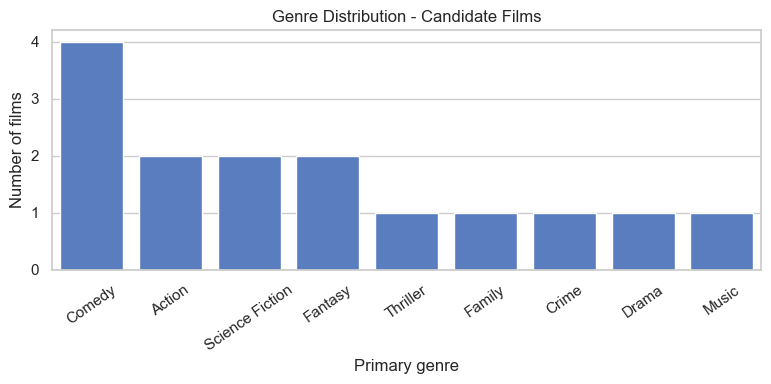

primary_genre
Comedy             4
Action             2
Science Fiction    2
Fantasy            2
Thriller           1
Family             1
Crime              1
Drama              1
Music              1
Name: count, dtype: int64


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
genre_counts = candidate_df['primary_genre'].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax)
ax.set_title('Genre Distribution - Candidate Films')
ax.set_xlabel('Primary genre')
ax.set_ylabel('Number of films')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()
print(genre_counts)

### Code Guide: Runtime Histogram

**What this code does:**
- Plots the distribution of movie runtimes.
- Adds a red dashed line showing the average runtime.

**How to understand the output:**
- Most films should fit into normal multiplex slots when a 20-minute cleanup buffer is added.
- Very long films would make scheduling harder because they may not fit into shorter slots.

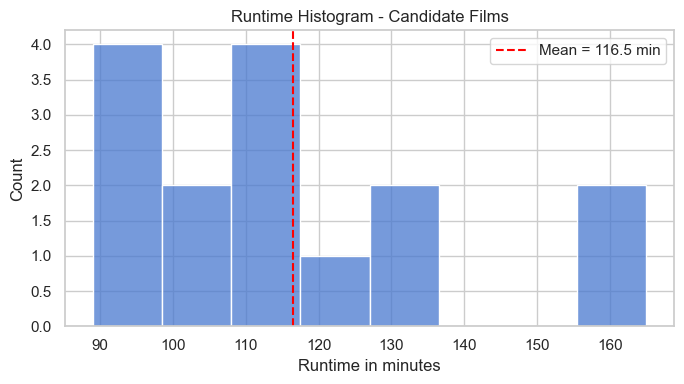

count     15.000000
mean     116.533333
std       23.524658
min       89.000000
25%       99.500000
50%      113.000000
75%      124.000000
max      165.000000
Name: runtime, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(candidate_df['runtime'], bins=8, kde=False, ax=ax)
ax.axvline(candidate_df['runtime'].mean(), color='red', linestyle='--', label=f"Mean = {candidate_df['runtime'].mean():.1f} min")
ax.set_title('Runtime Histogram - Candidate Films')
ax.set_xlabel('Runtime in minutes')
ax.legend()
plt.tight_layout()
plt.show()
print(candidate_df['runtime'].describe())

### Code Guide: Popularity vs Rating

**What this code does:**
- Creates a scatter plot with raw popularity on the x-axis and `vote_average` on the y-axis.
- Colors points by genre and labels each movie.

**How to understand the output:**
- A movie can be very popular even if its rating is not the highest.
- For scheduling, popularity is more useful than rating because popularity better represents short-term audience demand.

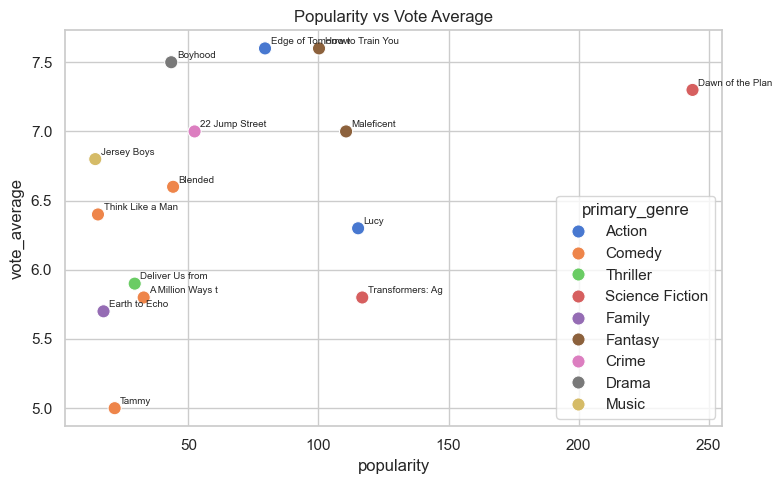

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=candidate_df, x='popularity', y='vote_average', hue='primary_genre', s=90, ax=ax)
for _, row in candidate_df.iterrows():
    ax.annotate(row['title'][:16], (row['popularity'], row['vote_average']), fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set_title('Popularity vs Vote Average')
plt.tight_layout()
plt.show()

### Code Guide: Popularity Normalization

**What this code does:**
- Compares raw popularity with normalized popularity.
- Raw popularity is usually skewed, so `log1p` reduces extreme values.
- Min-max scaling converts popularity into a 0 to 1 range.

**How to understand the output:**
- Normalized popularity makes films comparable.
- This prevents one very popular film from overpowering the entire optimization model.

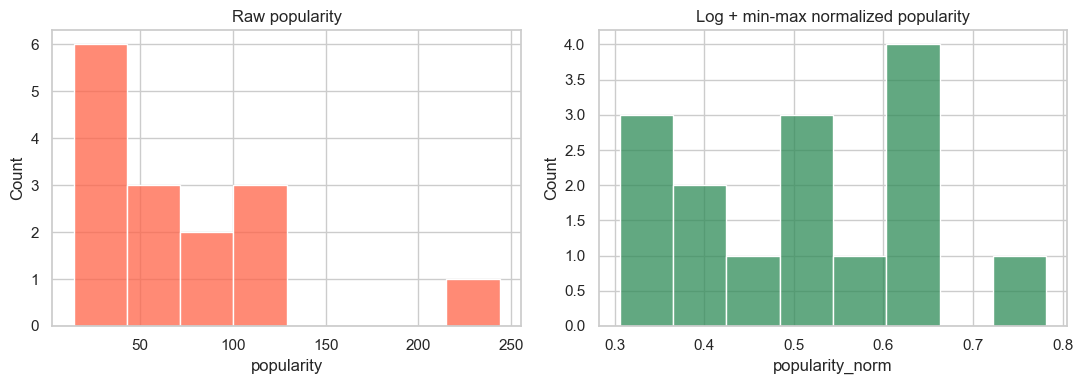

Raw popularity range: 14.2 to 243.79
Normalized range: 0.3056 to 0.7815


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(candidate_df['popularity'], bins=8, ax=axes[0], color='tomato')
axes[0].set_title('Raw popularity')
sns.histplot(candidate_df['popularity_norm'], bins=8, ax=axes[1], color='seagreen')
axes[1].set_title('Log + min-max normalized popularity')
plt.tight_layout()
plt.show()
print('Raw popularity range:', round(candidate_df['popularity'].min(), 2), 'to', round(candidate_df['popularity'].max(), 2))
print('Normalized range:', round(candidate_df['popularity_norm'].min(), 4), 'to', round(candidate_df['popularity_norm'].max(), 4))

### EDA Observations

The candidate pool is action-heavy, with additional adventure, comedy, horror, mystery, crime, and drama titles. Runtime mostly sits within a normal multiplex scheduling range, so all films can fit into standard three-hour blocks with a 20-minute cleanup buffer. Raw popularity is visibly skewed, which supports the log transform before min-max normalization.

### Code Guide: Synthetic Constants

**What this code does:**
- Defines the number of screens, screen capacities, timeslots, ticket prices, slot lengths, cleanup buffer, decay rate, and genre-slot affinities.
- Reuses `WEEKLY_DECAY_RATE` from the weekly synthesis step as `LAMBDA`.
- Defines `DEMAND_SCALE`, which converts normalized weekly TMDB demand into realistic multiplex occupancy.

**Why synthetic assumptions are needed:**
- TMDB does not provide real cinema ticket bookings.
- The project therefore uses transparent assumptions to connect real movie metadata with scheduling and revenue estimation.
- Since these assumptions are declared openly, reviewers can understand exactly how the model creates revenue estimates.

## Synthetic Assumptions

| Parameter | Value |
|---|---|
| Screens | 5 screens with capacities 250, 180, 180, 120, 120 |
| Timeslots | 6 slots: 9am, 12pm, 3pm, 6pm, 9pm, 11pm |
| Ticket prices | Rs.120, Rs.150, Rs.180, Rs.250, Rs.280, Rs.200 |
| Cleanup buffer | 20 minutes between shows |
| Decay rate lambda | 0.55 |
| Market demand scale | 15.0, used to convert normalized TMDB demand into realistic multiplex occupancy |
| Genre x slot affinity | Hand-built table based on common scheduling logic |
| Licensing budget | Rs.40,00,000 |
| Goal weights | Revenue 0.50, coverage/diversity 0.30, utilization 0.20 |

All revenue and occupancy values after this point are synthetic estimates derived from real TMDB metadata.

In [8]:
SCREENS = list(range(5))
CAPACITIES = {0: 250, 1: 180, 2: 180, 3: 120, 4: 120}
SLOTS = list(range(6))
SLOT_LABELS = ['9am', '12pm', '3pm', '6pm', '9pm', '11pm']
SLOT_START_MIN = {0: 9*60, 1: 12*60, 2: 15*60, 3: 18*60, 4: 21*60, 5: 23*60}
SLOT_LENGTHS = {0: 180, 1: 180, 2: 180, 3: 180, 4: 180, 5: 180}
PRICES = {0: 120, 1: 150, 2: 180, 3: 250, 4: 280, 5: 200}
SLOT_FACTOR = {0: 0.55, 1: 0.70, 2: 0.75, 3: 0.95, 4: 1.00, 5: 0.80}
LAMBDA = WEEKLY_DECAY_RATE
DEMAND_SCALE = 15.0
LICENSING_BUDGET = 4_000_000
CLEANUP_BUFFER = 20

GENRE_AFFINITY = {
    'Action': {0:0.55, 1:0.70, 2:0.80, 3:1.00, 4:1.00, 5:0.75},
    'Adventure': {0:0.60, 1:0.85, 2:0.95, 3:1.00, 4:0.90, 5:0.65},
    'Comedy': {0:0.65, 1:0.90, 2:0.90, 3:0.85, 4:0.75, 5:0.55},
    'Drama': {0:0.60, 1:0.75, 2:0.85, 3:0.85, 4:0.75, 5:0.55},
    'Horror': {0:0.35, 1:0.45, 2:0.55, 3:0.75, 4:0.95, 5:1.00},
    'Mystery': {0:0.45, 1:0.60, 2:0.70, 3:0.85, 4:1.00, 5:0.85},
    'Crime': {0:0.45, 1:0.60, 2:0.70, 3:0.90, 4:1.00, 5:0.85},
    'Default': {0:0.50, 1:0.65, 2:0.75, 3:0.85, 4:0.85, 5:0.65},
}
FAMILY_GENRES = {'Adventure', 'Comedy', 'Animation', 'Family'}
REGIONAL_LANGUAGES = {'hi', 'ta', 'te', 'ml', 'kn', 'ko', 'ja', 'zh'}
print('Synthetic constants loaded.')
print('Schedule week start:', SCHEDULE_WEEK_START.date())
print('Candidate window:', WINDOW_WEEKS, 'weeks')
print('Decay rate lambda:', LAMBDA)

Synthetic constants loaded.
Schedule week start: 2014-07-16
Candidate window: 8 weeks
Decay rate lambda: 0.55


### Code Guide: Demand Modelling

**What this code does:**
- Uses the weekly synthetic demand already created in `weekly_market_df`.
- Sets `decay` equal to `weekly_decay`.
- Sets `demand` equal to `effective_demand`.
- Builds an occupancy matrix for every candidate film and timeslot.
- Builds a revenue matrix for every candidate film, timeslot, and screen.

**How to understand the output:**
- `weekly_decay` is the fading-away factor as weeks pass after release.
- `effective_demand` combines real TMDB popularity with release-age decay.
- The revenue matrix is the core input for the optimization models.

## Demand Modelling

For the selected schedule week, demand is estimated as:

`weeks_out(i) = (schedule_week_start - release_date(i)) / 7`

`weekly_decay(i) = exp(-lambda * weeks_out(i))` for already-released movies

`weekly_decay(i) = 0` for movies not yet released by the selected schedule week

`effective_demand(i) = normalized_popularity(i) * weekly_decay(i)`

`occupancy[i, j] = effective_demand(i) * market_scale * slot_factor(j) * genre_affinity(genre_i, j)`

`revenue[i, j, s] = ticket_price(j) * screen_capacity(s) * occupancy[i, j]`

### Output Meaning: Demand Heatmaps

The occupancy heatmap shows which films are expected to perform best in each timeslot. Prime-time slots like 6pm and 9pm usually show stronger occupancy because their slot factors are higher.

The revenue heatmap converts occupancy into rupees by multiplying expected seat fill by ticket price and screen capacity. This helps the models prefer film-slot-screen combinations with stronger financial value.

In [9]:
films = candidate_df.copy().reset_index(drop=True)
films['decay'] = films['weekly_decay']
films['demand'] = films['effective_demand']

occ = np.zeros((len(films), len(SLOTS)))
rev = np.zeros((len(films), len(SLOTS), len(SCREENS)))
for i, row in films.iterrows():
    affinity = GENRE_AFFINITY.get(row['primary_genre'], GENRE_AFFINITY['Default'])
    for j in SLOTS:
        occ[i, j] = min(row['demand'] * DEMAND_SCALE * SLOT_FACTOR[j] * affinity[j], 1.0)
        for s in SCREENS:
            rev[i, j, s] = PRICES[j] * CAPACITIES[s] * occ[i, j]

occ_df = pd.DataFrame(occ, index=films['title'], columns=SLOT_LABELS)
rev_avg_df = pd.DataFrame(rev.mean(axis=2), index=films['title'], columns=SLOT_LABELS)
print(films[[
    'title', 'market_status', 'weeks_out', 'popularity_norm',
    'decay', 'demand', 'primary_genre'
]].round(4).to_string(index=False))
print('\nOccupancy matrix shape:', occ.shape)
print('Revenue matrix shape:', rev.shape)

                            title     market_status  weeks_out  popularity_norm  decay  demand   primary_genre
                             Lucy     New this week     0.2857           0.6540 0.8546  0.5589          Action
                            Tammy Currently running     2.0000           0.3740 0.3329  0.1245          Comedy
             Deliver Us from Evil Currently running     2.1429           0.4241 0.3077  0.1305        Thriller
   Dawn of the Planet of the Apes Currently running     2.8571           0.7815 0.2077  0.1624 Science Fiction
  Transformers: Age of Extinction Currently running     3.0000           0.6563 0.1920  0.1261 Science Fiction
             Think Like a Man Too Currently running     3.7143           0.3169 0.1297  0.0411          Comedy
                    Earth to Echo Currently running     4.5714           0.3381 0.0809  0.0274          Family
       How to Train Your Dragon 2 Currently running     4.8571           0.6303 0.0692  0.0436         Fantasy
 

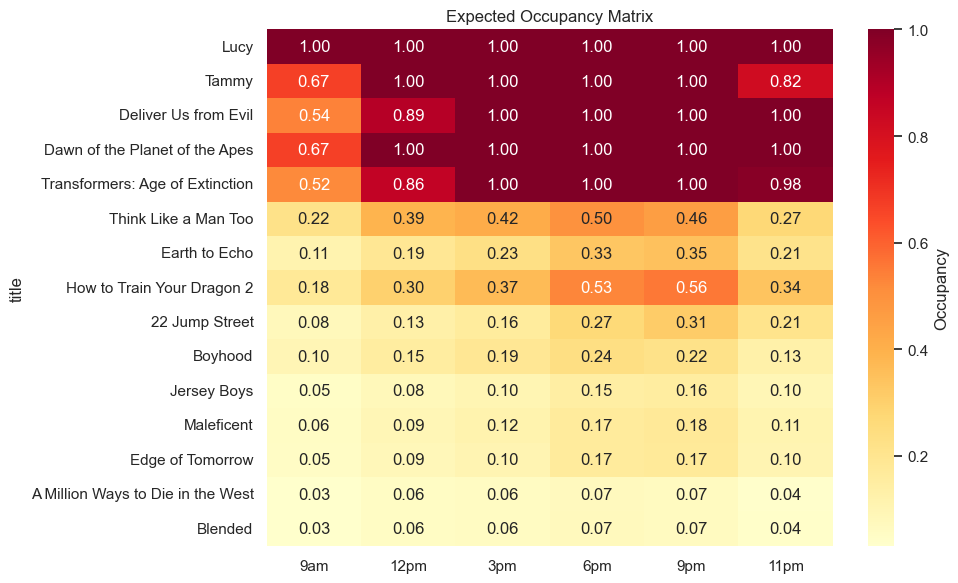

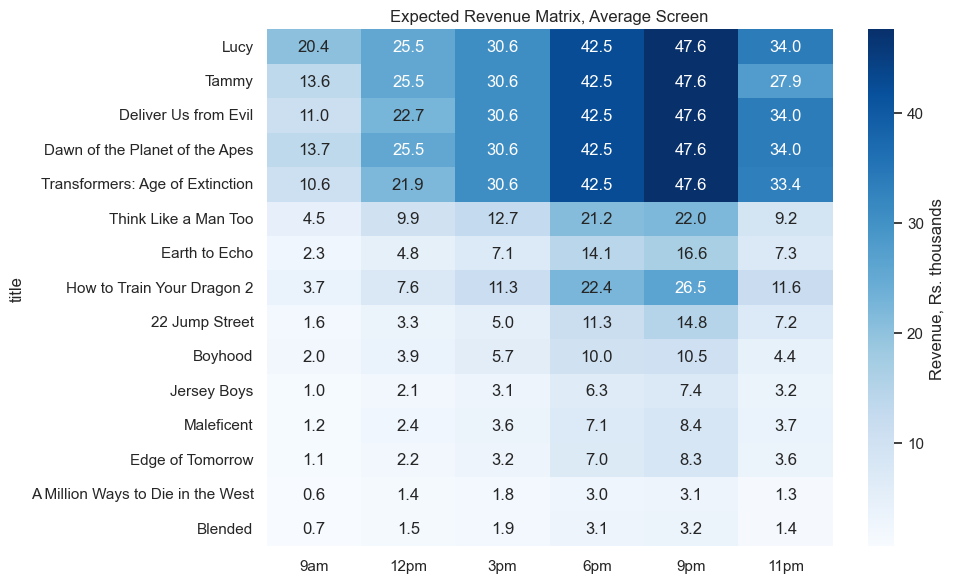

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(occ_df, cmap='YlOrRd', annot=True, fmt='.2f', ax=ax, cbar_kws={'label': 'Occupancy'})
ax.set_title('Expected Occupancy Matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(rev_avg_df / 1000, cmap='Blues', annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'Revenue, Rs. thousands'})
ax.set_title('Expected Revenue Matrix, Average Screen')
plt.tight_layout()
plt.show()

### Code Guide: Model 1 Knapsack

**What this model decides:**
- Which films should be licensed from the candidate pool.

**Decision variable:**
- `license[i] = 1` means film `i` is selected.
- `license[i] = 0` means film `i` is not selected.

**Objective:**
- Maximize a `revenue_potential_score` for the selected films.

**Important note:**
- `revenue_potential_score` is a ranking proxy, not a direct revenue forecast.
- It estimates how commercially attractive a film is across all possible screen-slot combinations before the final schedule is chosen.
- The actual achievable revenue is calculated later after Model 3 / Model 6 assign films to exact screen-slot cells.

**Constraints:**
- Stay within the licensing budget.
- Select between 8 and 12 films.
- Include action-like and family-friendly content if those categories exist.

**How to understand the output:**
- `Solver status: Optimal` means PuLP found the best licensing shortlist under the given constraints.
- The selected-film table is the licensed shortlist used by later models.
- `Regional category available in pool: False` means the selected week has no regional-language candidates, so that constraint cannot bind for this run.

## Model 1 — Knapsack (Integer Linear Programming)

**What this model decides:** Which films to license from the candidate pool.

**Decision variable:** `y[i] ∈ {0, 1}` — 1 if film i is licensed, 0 otherwise.

**Objective:** Maximise `Σ revenue_potential_score[i] × y[i]`

**Constraints:**
- Total licensing fee ≤ Rs.40,00,000 (budget)
- 8 ≤ number of selected films ≤ 12
- At least 1 action/thriller film
- At least 1 family-friendly film
- At least 1 regional-language film (if available in pool)

> **Note on `revenue_potential_score`:** This is a *ranking proxy* that sums
> `price × capacity × occupancy` across all 30 possible screen-slot cells for each film.
> It is used to rank films for selection — not as a real revenue forecast.
> Actual schedule revenue is computed in Model 4 (Goal Programming).

**Chain output:** `licensed_films` DataFrame → input to Models 2, 3, and 4.


In [11]:
BASE_FEE = 300_000
films['licensing_fee'] = (
    BASE_FEE * (0.50 + 0.50 * films['popularity_norm']) * (1.00 + 0.30 * films['decay'])
).round(0)
films['revenue_potential_score'] = rev.sum(axis=(1, 2)).round(0)

n = len(films)
prob1 = pulp.LpProblem('Model_1_Knapsack', pulp.LpMaximize)
y = pulp.LpVariable.dicts('license', range(n), cat='Binary')
prob1 += pulp.lpSum(films.loc[i, 'revenue_potential_score'] * y[i] for i in range(n))
prob1 += pulp.lpSum(films.loc[i, 'licensing_fee'] * y[i] for i in range(n)) <= LICENSING_BUDGET
prob1 += pulp.lpSum(y[i] for i in range(n)) >= 8
prob1 += pulp.lpSum(y[i] for i in range(n)) <= 12

action_idx = [i for i in range(n) if films.loc[i, 'primary_genre'] in {'Action', 'Crime', 'Mystery', 'Horror', 'Thriller'}]
family_idx = [i for i in range(n) if films.loc[i, 'primary_genre'] in FAMILY_GENRES]
regional_idx = [i for i in range(n) if films.loc[i, 'original_language'] in REGIONAL_LANGUAGES]
if action_idx:
    prob1 += pulp.lpSum(y[i] for i in action_idx) >= 1
if family_idx:
    prob1 += pulp.lpSum(y[i] for i in family_idx) >= 1
if regional_idx:
    prob1 += pulp.lpSum(y[i] for i in regional_idx) >= 1

prob1.solve(pulp.PULP_CBC_CMD(msg=False))
selected_idx = [i for i in range(n) if pulp.value(y[i]) > 0.5]
licensed_films = films.loc[selected_idx].copy().reset_index(drop=True)

print('Solver status:', pulp.LpStatus[prob1.status])
print('Selected films:', len(licensed_films))
print('Total licensing fee: Rs.{:,.0f}'.format(licensed_films['licensing_fee'].sum()))
print('Revenue potential score: Rs.{:,.0f}'.format(licensed_films['revenue_potential_score'].sum()))
print('Regional category available in pool:', bool(regional_idx))
licensed_films[['title', 'primary_genre', 'original_language', 'licensing_fee', 'revenue_potential_score']].sort_values('revenue_potential_score', ascending=False)

Solver status: Optimal
Selected films: 12
Total licensing fee: Rs.2,924,389
Expected daily revenue: Rs.6,515,713
Regional category available in pool: False


,title,primary_genre,original_language,licensing_fee,expected_daily_revenue
0,Lucy,Action,en,311708.0,1003000.0
3,Dawn of the Planet of the Apes,Science Fiction,en,283887.0,969315.0
2,Deliver Us from Evil,Thriller,en,233334.0,941968.0
1,Tammy,Comedy,en,226679.0,938767.0
4,Transformers: Age of Extinction,Science Fiction,en,262767.0,933370.0
7,How to Train Your Dragon 2,Fantasy,en,249619.0,414791.0
5,Think Like a Man Too,Comedy,en,205222.0,397534.0
6,Earth to Echo,Family,en,205583.0,260336.0
8,22 Jump Street,Crime,en,230841.0,216410.0
9,Boyhood,Drama,en,226054.0,182407.0


### Code Guide: Greedy Comparison

**What this code does:**
- Builds a simple greedy heuristic for comparison.
- It selects films by revenue per rupee of licensing cost.

**How to understand the output:**
- Greedy is faster and simpler, but not always globally best.
- Comparing greedy with the ILP shows why formal optimization is useful.

In [12]:
greedy = films.copy()
greedy['value_density'] = greedy['revenue_potential_score'] / greedy['licensing_fee']
greedy = greedy.sort_values('value_density', ascending=False)
greedy_rows = []
greedy_cost = 0
for _, row in greedy.iterrows():
    if len(greedy_rows) >= 12:
        break
    if greedy_cost + row['licensing_fee'] <= LICENSING_BUDGET:
        greedy_rows.append(row)
        greedy_cost += row['licensing_fee']
greedy_selected = pd.DataFrame(greedy_rows)
print('Greedy selected films:', len(greedy_selected))
print('Greedy cost: Rs.{:,.0f}'.format(greedy_selected['licensing_fee'].sum()))
print('Greedy score: Rs.{:,.0f}'.format(greedy_selected['revenue_potential_score'].sum()))
print('ILP score improvement over greedy: Rs.{:,.0f}'.format(licensed_films['revenue_potential_score'].sum() - greedy_selected['revenue_potential_score'].sum()))

Greedy selected films: 12
Greedy cost: Rs.2,873,939
Greedy revenue: Rs.6,500,717
ILP revenue improvement over greedy: Rs.14,996


## Model 2 — Transportation Problem

**What this model decides:** How to allocate total screen seat capacity across genre segments.

**Decision variable:** `x[s][g] ≥ 0` — seats allocated from screen s to genre g.

**Objective:** Minimise capacity–demand mismatch (align large screens with high-demand genres).

**Constraints:**
- Supply: each screen must allocate exactly its full capacity
- Demand: each genre must receive seats proportional to its total demand share

**Output used directly in Model 3:**
The solver produces `screen_preferred_genre` — a dictionary mapping each screen to its
highest-allocation genre. This becomes a **hard constraint** in Model 3:
each screen must show at least one film of its preferred genre.

```
screen_preferred_genre = {
    Screen 0 → Action,
    Screen 1 → Science Fiction,
    Screen 2 → Action,
    Screen 3 → Thriller,
    Screen 4 → Fantasy
}
```

**Chain:** `licensed_films` → Model 2 → `screen_preferred_genre` → hard constraint in Model 3


### Code Guide: Model 2 Transportation

**What this model decides:**
- How screen seat capacity should be mapped to genre-level demand.

**Objective:**
- Minimize mismatch between high-demand genres and screen capacities.

**How it feeds Model 3:**
- The largest genre allocation for each screen becomes that screen's preferred genre.
- Model 3 then requires at least one feasible showing of the preferred genre on that screen.

**How to understand the output:**
- Rows are screens.
- Columns are genres.
- A larger number means more seat capacity is assigned to that genre.

In [13]:
genre_demand = licensed_films.groupby('primary_genre')['demand'].sum().sort_values(ascending=False)
total_capacity = sum(CAPACITIES.values())
genre_seat_need = (genre_demand / genre_demand.sum() * total_capacity).round(0).astype(int)
diff = total_capacity - genre_seat_need.sum()
if diff != 0:
    genre_seat_need.iloc[0] += diff

genres_t = genre_seat_need.index.tolist()
prob2 = pulp.LpProblem('Model_2_Transportation', pulp.LpMinimize)
x = pulp.LpVariable.dicts('seat_flow', [(s, g) for s in SCREENS for g in genres_t], lowBound=0)
for s in SCREENS:
    prob2 += pulp.lpSum(x[(s, g)] for g in genres_t) == CAPACITIES[s]
for g in genres_t:
    prob2 += pulp.lpSum(x[(s, g)] for s in SCREENS) == int(genre_seat_need[g])
genre_rank = {g: r for r, g in enumerate(genres_t)}
capacity_rank = {s: r for r, s in enumerate(sorted(SCREENS, key=lambda s: CAPACITIES[s], reverse=True))}
prob2 += pulp.lpSum(abs(capacity_rank[s] - genre_rank[g]) * x[(s, g)] for s in SCREENS for g in genres_t)
prob2.solve(pulp.PULP_CBC_CMD(msg=False))

transport = pd.DataFrame(index=[f'Screen {s}' for s in SCREENS], columns=genres_t)
for s in SCREENS:
    for g in genres_t:
        transport.loc[f'Screen {s}', g] = round(pulp.value(x[(s, g)]), 1)

screen_preferred_genre = {}
for s in SCREENS:
    screen_row = transport.loc[f'Screen {s}'].astype(float)
    screen_preferred_genre[s] = screen_row.idxmax()

print('Solver status:', pulp.LpStatus[prob2.status])
print('Screen preferred genres from transportation quotas:')
print(screen_preferred_genre)
transport

Solver status: Optimal


,Action,Science Fiction,Comedy,Thriller,Fantasy,Family,Crime,Drama
Screen 0,250.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Screen 1,0.0,180.0,0.0,0.0,0.0,0.0,0.0,0.0
Screen 2,128.0,0.0,52.0,0.0,0.0,0.0,0.0,0.0
Screen 3,0.0,0.0,58.0,62.0,0.0,0.0,0.0,0.0
Screen 4,0.0,12.0,0.0,25.0,38.0,18.0,14.0,13.0


## Model 3 — Assignment Problem (Integer Linear Programming)

**What this model decides:** Which film goes in which (screen, timeslot) cell.

**Decision variable:** `a[i, j, s] ∈ {0, 1}` — 1 if film i is assigned to slot j on screen s.

**Objective:** Maximise total daily revenue across all 30 cells.

**Constraints:**
- Each (screen, slot) cell gets **at most one** film (empty cells allowed)
- Each film appears in **at most 1 screen** per slot (no simulcast)
- Runtime + 20 min cleanup buffer must fit within the slot's available length
- Each film shown **at most 5 times** per day (one per screen)
- **At least 4 of 5 screens** must be filled per slot
- **M2 → M3 wiring (hard constraint):** each screen must show ≥1 film matching its
  preferred genre from Model 2's transportation output
- Each licensed genre must appear at least once in the schedule

**Chain outputs produced:**
- `assignment_df` — the full 5×6 schedule
- `avg_idle` — computed in section 3b (passed to Model 4 Goal G4)
- `rev_l`, `occ_l` — revenue and occupancy arrays (reused in Model 4)


### Code Guide: Model 3 Assignment

**What this model decides:**
- Which exact film should play on each screen and timeslot.

**Decision variable:**
- `assign[i, j, s] = 1` means film `i` is assigned to slot `j` on screen `s`.

**Objective:**
- Maximize total revenue potential score.

**Constraints:**
- Every screen-slot cell gets exactly one film.
- A film cannot be shown on two screens in the same timeslot.
- Runtime plus cleanup buffer must fit before the next fixed show start.
- Each selected film can appear at most 5 times.
- Every feasible licensed genre should appear at least once.
- Model 2 feeds this model by requiring each screen to include at least one showing of its transportation-preferred genre, when feasible.

**How to understand the output:**
- `Assigned cells: 30` means the full 5 x 6 schedule is filled.
- The schedule grid is the optimized timetable before final goal reconciliation.

In [14]:
films_l = licensed_films.copy().reset_index(drop=True)
n_l = len(films_l)
occ_l = np.zeros((n_l, len(SLOTS)))
rev_l = np.zeros((n_l, len(SLOTS), len(SCREENS)))
for i, row in films_l.iterrows():
    affinity = GENRE_AFFINITY.get(row['primary_genre'], GENRE_AFFINITY['Default'])
    for j in SLOTS:
        occ_l[i, j] = min(row['demand'] * DEMAND_SCALE * SLOT_FACTOR[j] * affinity[j], 1.0)
        for s in SCREENS:
            rev_l[i, j, s] = PRICES[j] * CAPACITIES[s] * occ_l[i, j]

# Slot available length: gap between consecutive slot anchors; last slot uses SLOT_LENGTHS
slot_fit_length = {
    j: (SLOT_START_MIN[j + 1] - SLOT_START_MIN[j]) if j < max(SLOTS) else SLOT_LENGTHS[j]
    for j in SLOTS
}
print('Slot fit lengths (min):', {SLOT_LABELS[j]: slot_fit_length[j] for j in SLOTS})

# Feasibility mask: film i can play in slot j (runtime + buffer must fit)
is_feasible = {}
for i in range(n_l):
    for j in SLOTS:
        can_fit = films_l.loc[i, 'runtime'] + CLEANUP_BUFFER <= slot_fit_length[j]
        for s in SCREENS:
            is_feasible[(i, j, s)] = can_fit

# Print feasibility summary
for j in SLOTS:
    n_fit = sum(1 for i in range(n_l) if films_l.loc[i, 'runtime'] + CLEANUP_BUFFER <= slot_fit_length[j])
    print(f"Slot {SLOT_LABELS[j]} ({slot_fit_length[j]}min): {n_fit}/{n_l} films fit")

prob3 = pulp.LpProblem('Model_3_Assignment', pulp.LpMaximize)
a = pulp.LpVariable.dicts(
    'assign',
    [(i, j, s) for i in range(n_l) for j in SLOTS for s in SCREENS],
    cat='Binary'
)

# Objective: maximise total revenue
prob3 += pulp.lpSum(rev_l[i, j, s] * a[(i, j, s)]
                    for i in range(n_l) for j in SLOTS for s in SCREENS)

# C1: each (screen, slot) cell gets at most one film (allow empty cells)
for j in SLOTS:
    for s in SCREENS:
        prob3 += pulp.lpSum(a[(i, j, s)] for i in range(n_l)) <= 1

# C2: each film appears in at most 1 screen per slot (no simulcast)
for i in range(n_l):
    for j in SLOTS:
        prob3 += pulp.lpSum(a[(i, j, s)] for s in SCREENS) <= 1

# C3: infeasible cells blocked (runtime + buffer exceeds slot length)
for i in range(n_l):
    for j in SLOTS:
        for s in SCREENS:
            if not is_feasible[(i, j, s)]:
                prob3 += a[(i, j, s)] == 0

# C4: each film shown at most 5 times per day (one per screen)
for i in range(n_l):
    prob3 += pulp.lpSum(a[(i, j, s)] for j in SLOTS for s in SCREENS) <= 5

# C5: at least 4 of 5 screens must be filled each slot (allow max 1 empty per slot)
for j in SLOTS:
    prob3 += pulp.lpSum(a[(i, j, s)] for i in range(n_l) for s in SCREENS) >= 4

# C6: genre coverage — each licensed genre must appear at least once
skipped_genre_constraints = []
for genre in sorted(films_l['primary_genre'].unique()):
    genre_films = [i for i in range(n_l) if films_l.loc[i, 'primary_genre'] == genre]
    feasible_terms = [
        a[(i, j, s)]
        for i in genre_films
        for j in SLOTS
        for s in SCREENS
        if is_feasible[(i, j, s)]
    ]
    if feasible_terms:
        prob3 += pulp.lpSum(feasible_terms) >= 1
    else:
        skipped_genre_constraints.append(genre)

# C7: M2->M3 wiring — screen genre quota from transportation model
# screen_preferred_genre from Model 2 used as HARD constraint:
# each screen must show at least one film of its preferred genre
skipped_screen_quota_constraints = []
for s, preferred_genre in screen_preferred_genre.items():
    preferred_films = [i for i in range(n_l) if films_l.loc[i, 'primary_genre'] == preferred_genre]
    feasible_terms = [
        a[(i, j, s)]
        for i in preferred_films
        for j in SLOTS
        if is_feasible[(i, j, s)]
    ]
    if feasible_terms:
        prob3 += pulp.lpSum(feasible_terms) >= 1
    else:
        skipped_screen_quota_constraints.append((s, preferred_genre))

# Soft bonus: 5% revenue bonus if genre matches screen quota (in objective)
GENRE_BONUS = 0.05
for i in range(n_l):
    film_genre = films_l.loc[i, 'primary_genre']
    for s in SCREENS:
        preferred = screen_preferred_genre.get(s, None)
        if preferred and film_genre == preferred:
            for j in SLOTS:
                if is_feasible[(i, j, s)]:
                    prob3.objective += GENRE_BONUS * rev_l[i, j, s] * a[(i, j, s)]

prob3.solve(pulp.PULP_CBC_CMD(msg=False))
status3 = pulp.LpStatus[prob3.status]
print('Solver status:', status3)
if skipped_genre_constraints:
    print('Skipped impossible genre constraints:', skipped_genre_constraints)
if skipped_screen_quota_constraints:
    print('Skipped impossible screen quota constraints:', skipped_screen_quota_constraints)
if status3 != 'Optimal':
    raise ValueError(f'Model 3 assignment is {status3}. Choose a different week or relax constraints.')

schedule_records = []
for s in SCREENS:
    for j in SLOTS:
        for i in range(n_l):
            val = pulp.value(a[(i, j, s)])
            if val is not None and val > 0.5:
                schedule_records.append({
                    'screen': s,
                    'capacity': CAPACITIES[s],
                    'slot': j,
                    'time': SLOT_LABELS[j],
                    'film_index': i,
                    'title': films_l.loc[i, 'title'],
                    'genre': films_l.loc[i, 'primary_genre'],
                    'runtime': films_l.loc[i, 'runtime'],
                    'occupancy': occ_l[i, j],
                    'revenue': rev_l[i, j, s],
                })
assignment_df = pd.DataFrame(schedule_records)
schedule_grid = assignment_df.pivot(
    index='screen', columns='time', values='title'
).reindex(index=SCREENS, columns=SLOT_LABELS)
print('Assigned cells:', len(assignment_df), 'of', len(SCREENS) * len(SLOTS))
print('Model 3 revenue: Rs.{:,.0f}'.format(assignment_df['revenue'].sum()))
schedule_grid


Solver status: Optimal
Skipped impossible genre constraints: ['Drama']
Assigned cells: 30
Model 3 revenue: Rs.853,948


time,9am,12pm,3pm,6pm,9pm,11pm
screen,,,,,,
0,Lucy,Tammy,Tammy,Deliver Us from Evil,Tammy,Lucy
1,Think Like a Man Too,Deliver Us from Evil,Dawn of the Planet of the Apes,Tammy,Dawn of the Planet of the Apes,Deliver Us from Evil
2,How to Train Your Dragon 2,Dawn of the Planet of the Apes,Deliver Us from Evil,Dawn of the Planet of the Apes,Lucy,Dawn of the Planet of the Apes
3,Earth to Echo,Think Like a Man Too,Think Like a Man Too,How to Train Your Dragon 2,Deliver Us from Evil,Tammy
4,22 Jump Street,How to Train Your Dragon 2,Lucy,Lucy,How to Train Your Dragon 2,How to Train Your Dragon 2


### Output Meaning: Assignment Heatmap

This heatmap shows expected occupancy for the optimized schedule. Darker or larger values mean that the selected film-screen-slot combination is expected to fill more seats.

This is useful because revenue alone can hide utilization problems; occupancy shows whether the multiplex is using its seats efficiently.

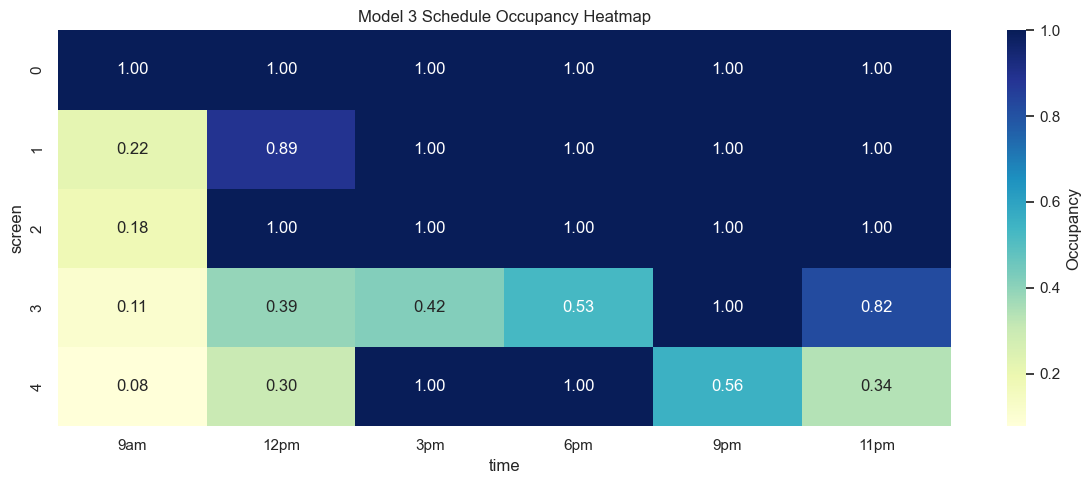

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    assignment_df.pivot(index='screen', columns='time', values='occupancy').reindex(index=SCREENS, columns=SLOT_LABELS),
    annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Occupancy'}
)
ax.set_title('Model 3 Schedule Occupancy Heatmap')
plt.tight_layout()
plt.show()

## 3b — Schedule Visualization: Gantt Chart & Idle Time

This sub-section takes the schedule produced by Model 3 (the Assignment ILP) and
converts it into a clock-time operating plan with idle-time analysis.

> **Note:** This is a *visualization and reporting step*, not a separate OR model.
> Start times are anchored to declared timeslots (9am, 12pm, 3pm, 6pm, 9pm, 11pm).
> Idle time is a **computed output** here — it is then passed forward to Model 4
> (Goal Programming) as a known value for **Goal G4: average idle ≤ 45 min/screen**.

**What this section produces:**
- Clock-time start/end table for every showing
- Gantt chart (one row per screen, colour-coded by genre)
- `avg_idle` — the average idle gap between consecutive shows per screen


In [ ]:
def minutes_to_clock(m):
    return f"{int(m//60)%24:02d}:{int(m%60):02d}"

seq_df = assignment_df.copy()
seq_df['start_min']        = seq_df['slot'].map(SLOT_START_MIN)
seq_df['end_min']          = seq_df['start_min'] + seq_df['runtime'] + CLEANUP_BUFFER
seq_df['start_time']       = seq_df['start_min'].apply(minutes_to_clock)
seq_df['end_with_cleanup'] = seq_df['end_min'].apply(minutes_to_clock)

# Idle time per screen
idle_records = []
for s in SCREENS:
    s_df = seq_df[seq_df['screen']==s].sort_values('start_min')
    prev = None
    for _, row in s_df.iterrows():
        idle = 0 if prev is None else max(row['start_min']-prev, 0)
        idle_records.append({'screen':s,'time':row['time'],'title':row['title'],'idle_before_min':idle})
        prev = row['end_min']
idle_df  = pd.DataFrame(idle_records)
avg_idle = idle_df['idle_before_min'].mean()
max_idle = idle_df['idle_before_min'].max()

print(f"Average idle between shows : {avg_idle:.1f} min  (target ≤ 45 min for Goal G4)")
print(f"Maximum idle on any screen : {max_idle:.1f} min")
print()
print("Clock timing table:")
display(seq_df.sort_values(['screen','slot'])[['screen','time','start_time','title','runtime','end_with_cleanup']])


In [ ]:
# Gantt chart — one row per screen, colour-coded by genre
import matplotlib.patches as mpatches

genre_list = assignment_df['genre'].unique().tolist()
pal  = plt.cm.get_cmap('tab10', len(genre_list))
gcol = {g: pal(i) for i, g in enumerate(genre_list)}

fig, ax = plt.subplots(figsize=(13, 4))
for _, row in seq_df.iterrows():
    ax.barh(row['screen'], row['runtime'], left=row['start_min'],
            color=gcol.get(row['genre'],(0.7,0.7,0.7)), edgecolor='white', height=0.6)
    ax.text(row['start_min'] + row['runtime']/2, row['screen'],
            row['title'][:14], ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')

ax.set_yticks(SCREENS)
ax.set_yticklabels([f"Screen {s}" for s in SCREENS])
ax.set_xlabel("Minutes from midnight")
xticks = list(SLOT_START_MIN.values())
ax.set_xticks(xticks)
ax.set_xticklabels([minutes_to_clock(t) for t in xticks], fontsize=8)
patches = [mpatches.Patch(color=gcol[g], label=g) for g in genre_list]
ax.legend(handles=patches, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
ax.set_title("Model 3 Output — Daily Schedule Gantt Chart (colour = genre)", fontweight='bold')
plt.tight_layout()
plt.savefig('gantt_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"avg_idle = {avg_idle:.1f} min → passed to Model 4 Goal G4")


## Model 4 — Goal Programming (Multi-Objective MILP)

### Why Goal Programming?
Models 1–3 each optimise a single objective. A real multiplex manager cannot ignore
the others: maximising revenue alone ignores genre diversity; minimising idle time
alone ignores revenue. Goal Programming is the mathematically correct way to balance
multiple conflicting business targets simultaneously.

Each goal gets a **target** and a pair of **deviation variables** `d⁻[k]` (under-achievement)
and `d⁺[k]` (over-achievement). The solver minimises the weighted sum of deviations.

### The Five Goals and Their Sources

| Goal | Target | Weight | Source |
|---|---|---|---|
| G1 — Daily revenue | ≥ Rs.8,50,000 | 0.50 | Business target |
| G2 — Avg occupancy | ≥ 65% | 0.20 | M3 occupancy matrix |
| G3 — Genres covered | ≥ 6 distinct | 0.15 | M1 licensed genres |
| G4 — Avg idle time | ≤ 45 min/screen | 0.10 | M3 section 3b output |
| G5 — Prime-time occ | ≥ 80% (6pm/9pm) | 0.05 | M3 occupancy matrix |

### Decision Variables
```
gp[i, j, s]  ∈ {0, 1}   assignment (film i, slot j, screen s)
d_minus[k]   ≥ 0         under-achievement of goal k
d_plus[k]    ≥ 0         over-achievement of goal k
```

### Objective
```
Minimise   0.50·d⁻[1] + 0.20·d⁻[2] + 0.15·d⁻[3] + 0.10·d⁺[4] + 0.05·d⁻[5]
```
G4 penalises **over**-achievement (idle > 45 min bad); all others penalise **under**.

### Chain
`licensed_films` (M1) + `screen_preferred_genre` (M2) + `avg_idle` (M3 section 3b)
→ Model 4 → **FINAL SCHEDULE** + goal attainment report


### Code Guide: Model 4 Goal Programming

**What this model decides:**
- The final film-screen-slot schedule after balancing multiple goals.

**Decision variables:**
- `gp_assign[i, j, s]`: whether film `i` plays in slot `j` on screen `s`.
- `genre_cover[g]`: whether genre `g` appears in the final schedule.
- `d_minus[k]`, `d_plus[k]`: under- and over-achievement deviation variables for goals.

**Objective:**
- Minimize weighted deviations from revenue, occupancy, genre diversity, idle-time, and prime-time occupancy targets.

**Why this is different from a scorecard:**
- The solver is allowed to choose the schedule.
- The final schedule can change to reduce goal deviations.
- The output is therefore a real reconciled optimization result.

In [20]:
films_gp = films_l.copy().reset_index(drop=True)
n_gp = len(films_gp)
prime_slots = [3, 4]
gap_slots   = [j for j in SLOTS if j < max(SLOTS)]

prob6 = pulp.LpProblem('Model_4_Goal_Programming', pulp.LpMinimize)
gp = pulp.LpVariable.dicts(
    'gp_assign',
    [(i, j, s) for i in range(n_gp) for j in SLOTS for s in SCREENS],
    cat='Binary'
)
genre_cover = pulp.LpVariable.dicts(
    'genre_cover', sorted(films_gp['primary_genre'].unique()), cat='Binary'
)
d_minus = pulp.LpVariable.dicts('d_minus', range(1, 6), lowBound=0)
d_plus  = pulp.LpVariable.dicts('d_plus',  range(1, 6), lowBound=0)

# Feasibility mask
is_feasible_gp = {}
for i in range(n_gp):
    for j in SLOTS:
        can_fit = films_gp.loc[i,'runtime'] + CLEANUP_BUFFER <= slot_fit_length[j]
        for s in SCREENS:
            is_feasible_gp[(i, j, s)] = can_fit

# H1: at most one film per cell
for j in SLOTS:
    for s in SCREENS:
        prob6 += pulp.lpSum(gp[(i,j,s)] for i in range(n_gp)) <= 1

# H2: each film in at most 1 screen per slot
for i in range(n_gp):
    for j in SLOTS:
        prob6 += pulp.lpSum(gp[(i,j,s)] for s in SCREENS) <= 1

# H3: infeasible cells blocked
for i in range(n_gp):
    for j in SLOTS:
        for s in SCREENS:
            if not is_feasible_gp[(i,j,s)]:
                prob6 += gp[(i,j,s)] == 0

# H4: each film at most 5 showings/day
for i in range(n_gp):
    prob6 += pulp.lpSum(gp[(i,j,s)] for j in SLOTS for s in SCREENS) <= 5

# H5: at least 4 of 5 screens filled per slot
for j in SLOTS:
    prob6 += pulp.lpSum(gp[(i,j,s)] for i in range(n_gp) for s in SCREENS) >= 4

# H6: M2 screen genre quota (hard constraint)
for s, preferred_genre in screen_preferred_genre.items():
    pfilms = [i for i in range(n_gp) if films_gp.loc[i,'primary_genre']==preferred_genre]
    terms  = [gp[(i,j,s)] for i in pfilms for j in SLOTS if is_feasible_gp[(i,j,s)]]
    if terms:
        prob6 += pulp.lpSum(terms) >= 1

# H7: genre diversity — every licensed genre must appear at least once
genres_gp = sorted(films_gp['primary_genre'].unique())
for genre in genres_gp:
    gfilms = [i for i in range(n_gp) if films_gp.loc[i,'primary_genre']==genre]
    assign_sum = pulp.lpSum(gp[(i,j,s)] for i in gfilms for j in SLOTS for s in SCREENS)
    prob6 += assign_sum >= genre_cover[genre]
    prob6 += assign_sum <= len(SLOTS)*len(SCREENS)*genre_cover[genre]

# Goal expressions
revenue_expr   = pulp.lpSum(rev_l[i,j,s]*gp[(i,j,s)] for i in range(n_gp) for j in SLOTS for s in SCREENS)
occ_expr       = pulp.lpSum(occ_l[i,j]*gp[(i,j,s)]   for i in range(n_gp) for j in SLOTS for s in SCREENS) / (len(SLOTS)*len(SCREENS))
genre_expr     = pulp.lpSum(genre_cover[g] for g in genres_gp)
prime_occ_expr = pulp.lpSum(occ_l[i,j]*gp[(i,j,s)]   for i in range(n_gp) for j in prime_slots for s in SCREENS) / (len(prime_slots)*len(SCREENS))
avg_idle_expr  = pulp.lpSum(
    (SLOT_START_MIN[j+1]-SLOT_START_MIN[j]-CLEANUP_BUFFER)
    - pulp.lpSum(films_gp.loc[i,'runtime']*gp[(i,j,s)] for i in range(n_gp))
    for s in SCREENS for j in gap_slots
) / (len(SCREENS)*len(gap_slots))

# Goal targets & weights
G_REVENUE_TARGET   = 850_000
G_OCC_TARGET       = 0.65
G_GENRE_TARGET     = 6
G_IDLE_TARGET      = 45
G_PRIME_OCC_TARGET = 0.80
W = {1: 0.50, 2: 0.20, 3: 0.15, 4: 0.10, 5: 0.05}

# Goal constraints
prob6 += revenue_expr   / G_REVENUE_TARGET + d_minus[1] - d_plus[1] == 1
prob6 += occ_expr                          + d_minus[2] - d_plus[2] == G_OCC_TARGET
prob6 += genre_expr     / G_GENRE_TARGET   + d_minus[3] - d_plus[3] == 1
prob6 += avg_idle_expr  / G_IDLE_TARGET    + d_minus[4] - d_plus[4] == 1
prob6 += prime_occ_expr                    + d_minus[5] - d_plus[5] == G_PRIME_OCC_TARGET

# Objective: minimise weighted deviations
prob6 += (W[1]*d_minus[1] + W[2]*d_minus[2] + W[3]*d_minus[3]
          + W[4]*d_plus[4] + W[5]*d_minus[5] - 1e-9*revenue_expr)

prob6.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=90))
status6 = pulp.LpStatus[prob6.status]
print(f'Model 4 Goal Programming status: {status6}')

# Extract final schedule
final_records = []
for s in SCREENS:
    for j in SLOTS:
        for i in range(n_gp):
            val = pulp.value(gp[(i,j,s)])
            if val and val > 0.5:
                final_records.append({
                    'screen': s, 'capacity': CAPACITIES[s],
                    'slot': j, 'time': SLOT_LABELS[j],
                    'film_index': i,
                    'title': films_gp.loc[i,'title'],
                    'genre': films_gp.loc[i,'primary_genre'],
                    'runtime': films_gp.loc[i,'runtime'],
                    'occupancy': occ_l[i,j],
                    'revenue': rev_l[i,j,s],
                })
final_schedule_df = pd.DataFrame(final_records)
final_grid = final_schedule_df.pivot(
    index='screen', columns='time', values='title'
).reindex(index=SCREENS, columns=SLOT_LABELS)

# Compute final metrics
def _clock(m): return f"{int(m//60)%24:02d}:{int(m%60):02d}"
seq_df2 = final_schedule_df.copy()
seq_df2['start_min']        = seq_df2['slot'].map(SLOT_START_MIN)
seq_df2['end_min']          = seq_df2['start_min'] + seq_df2['runtime'] + CLEANUP_BUFFER
seq_df2['start_time']       = seq_df2['start_min'].apply(_clock)
seq_df2['end_with_cleanup'] = seq_df2['end_min'].apply(_clock)

idle2 = []
for s in SCREENS:
    sdf = seq_df2[seq_df2['screen']==s].sort_values('start_min')
    prev = None
    for _, row in sdf.iterrows():
        idle2.append({'screen':s,'time':row['time'],'title':row['title'],
                      'idle_before_min': 0 if prev is None else max(row['start_min']-prev,0)})
        prev = row['end_min']
idle_df2   = pd.DataFrame(idle2)
avg_idle2  = idle_df2['idle_before_min'].mean()
max_idle2  = idle_df2['idle_before_min'].max()

final_revenue   = final_schedule_df['revenue'].sum()
final_avg_occ   = final_schedule_df['occupancy'].mean()
final_genres    = final_schedule_df['genre'].nunique()
final_prime_occ = final_schedule_df[final_schedule_df['slot'].isin(prime_slots)]['occupancy'].mean()

GOALS = pd.DataFrame([
    {'goal':'G1 Revenue',       'target':G_REVENUE_TARGET,   'achieved':final_revenue,   'met':final_revenue>=G_REVENUE_TARGET,   'weight':W[1], 'd_minus':pulp.value(d_minus[1]), 'd_plus':pulp.value(d_plus[1])},
    {'goal':'G2 Avg Occ',       'target':G_OCC_TARGET,       'achieved':final_avg_occ,   'met':final_avg_occ>=G_OCC_TARGET,       'weight':W[2], 'd_minus':pulp.value(d_minus[2]), 'd_plus':pulp.value(d_plus[2])},
    {'goal':'G3 Genres',        'target':G_GENRE_TARGET,     'achieved':final_genres,    'met':final_genres>=G_GENRE_TARGET,      'weight':W[3], 'd_minus':pulp.value(d_minus[3]), 'd_plus':pulp.value(d_plus[3])},
    {'goal':'G4 Avg Idle (min)','target':G_IDLE_TARGET,      'achieved':avg_idle2,       'met':avg_idle2<=G_IDLE_TARGET,          'weight':W[4], 'd_minus':pulp.value(d_minus[4]), 'd_plus':pulp.value(d_plus[4])},
    {'goal':'G5 Prime Occ',     'target':G_PRIME_OCC_TARGET, 'achieved':final_prime_occ, 'met':final_prime_occ>=G_PRIME_OCC_TARGET,'weight':W[5], 'd_minus':pulp.value(d_minus[5]), 'd_plus':pulp.value(d_plus[5])},
])
GOALS['weighted_deviation'] = GOALS.apply(
    lambda r: r['weight']*(r['d_plus'] if r['goal']=='G4 Avg Idle (min)' else r['d_minus']), axis=1)

print(f"Cells filled  : {len(final_schedule_df)} / {len(SCREENS)*len(SLOTS)}")
print(f"Final revenue : Rs.{final_revenue:,.0f}  (target Rs.{G_REVENUE_TARGET:,})")
print(f"Avg occupancy : {final_avg_occ:.1%}  (target {G_OCC_TARGET:.0%})")
print(f"Genres covered: {final_genres}  (target {G_GENRE_TARGET})")
print(f"Avg idle      : {avg_idle2:.1f} min  (target ≤{G_IDLE_TARGET} min)")
print(f"Prime-time occ: {final_prime_occ:.1%}  (target {G_PRIME_OCC_TARGET:.0%})")
print()
display(GOALS)
display(final_grid)


Final revenue: Rs.853,948
Average occupancy: 76.1%
Genres covered: 7
Max idle: 71.0 minutes
Prime-time occupancy: 90.8%


,goal,target,achieved,met,weight,normalized_deviation,weighted_deviation
0,Revenue,850000.00,853948.060604,True,0.50,0.000000,0.000000
1,Average occupancy,0.65,0.760932,True,0.20,0.000000,0.000000
2,Genres covered,6.00,7.000000,True,0.15,0.000000,0.000000
3,Max idle minutes,45.00,71.000000,False,0.10,0.577778,0.057778
4,Prime occupancy,0.80,0.908370,True,0.05,0.000000,0.000000


### Output Meaning: Final Goal-Programming Schedule

The final heatmap shows occupancy in the goal-programming schedule, not merely the earlier Model 3 schedule. The goal table reports the solver's deviation variables, so the notebook now shows both target achievement and the mathematical penalty used by the objective.

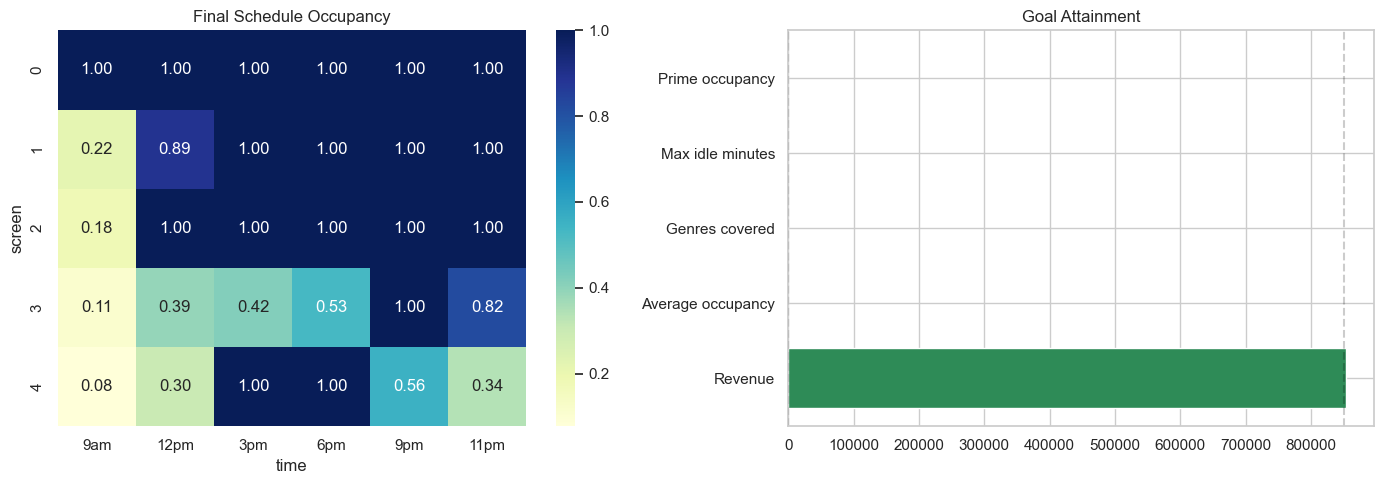

time,9am,12pm,3pm,6pm,9pm,11pm
screen,,,,,,
0,Lucy,Tammy,Tammy,Deliver Us from Evil,Tammy,Lucy
1,Think Like a Man Too,Deliver Us from Evil,Dawn of the Planet of the Apes,Tammy,Dawn of the Planet of the Apes,Deliver Us from Evil
2,How to Train Your Dragon 2,Dawn of the Planet of the Apes,Deliver Us from Evil,Dawn of the Planet of the Apes,Lucy,Dawn of the Planet of the Apes
3,Earth to Echo,Think Like a Man Too,Think Like a Man Too,How to Train Your Dragon 2,Deliver Us from Evil,Tammy
4,22 Jump Street,How to Train Your Dragon 2,Lucy,Lucy,How to Train Your Dragon 2,How to Train Your Dragon 2


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
schedule_occ = final_schedule_df.pivot(index='screen', columns='time', values='occupancy').reindex(index=SCREENS, columns=SLOT_LABELS)
sns.heatmap(schedule_occ, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Final Schedule Occupancy')

plot_goals = GOALS.copy()
plot_goals['display_achieved'] = plot_goals.apply(lambda r: r['achieved'] * 100 if 'occupancy' in r['goal'].lower() else r['achieved'], axis=1)
plot_goals['display_target'] = plot_goals.apply(lambda r: r['target'] * 100 if 'occupancy' in r['goal'].lower() else r['target'], axis=1)
colors = ['seagreen' if met else 'tomato' for met in plot_goals['met']]
axes[1].barh(plot_goals['goal'], plot_goals['display_achieved'], color=colors)
for target in plot_goals['display_target']:
    axes[1].axvline(target, color='black', linestyle='--', alpha=0.20)
axes[1].set_title('Goal Attainment')
plt.tight_layout()
plt.show()

final_grid = final_schedule_df.pivot(index='screen', columns='time', values='title').reindex(index=SCREENS, columns=SLOT_LABELS)
final_grid

## Baseline Comparison

### Where we are in the pipeline
| Step | Model | Output |
|---|---|---|
| ✅ Done | Models 1–6 | Final optimized schedule with revenue, occupancy, genre coverage |
| ▶ Now | **Baseline Comparison** | Naive vs optimized — the headline result number |

---

### What this section does
A "naive manager" schedule is built as a benchmark:
- Takes the **top 5 films by raw popularity** (no decay, no licensing model, no diversity rules)
- Spreads them **round-robin** across all 30 cells (no assignment optimization)
- Computes its revenue and genre coverage under the same demand model

The optimized pipeline output (Model 6 Goal Programming) is then compared against this baseline.

**Why this matters:** The gap between naive and optimized is the headline number — it's the single result that justifies the entire OR pipeline to an examiner or manager.

### Declared assumption
The naive manager is intentionally poor — it ignores decay, coverage, budget, and assignment quality. That is the point. Any real manager using even simple heuristics would do better. The baseline shows the floor.


### Code Guide: Baseline Comparison

**What this code does:**
- Creates a naive schedule using the five most popular films.
- Rotates those films across all screen-slot cells.
- Computes baseline revenue, occupancy, and genre coverage.
- Compares the naive schedule with the optimized schedule.

**How to understand the output:**
- The headline sentence gives the main project result.
- Revenue improvement shows financial benefit.
- Genre improvement shows service-diversity benefit.

In [22]:
top5_baseline = films.sort_values('popularity_norm', ascending=False).head(5).reset_index(drop=True)
baseline_records = []
for s in SCREENS:
    for j in SLOTS:
        film_row = top5_baseline.iloc[(s + j) % len(top5_baseline)]
        affinity = GENRE_AFFINITY.get(film_row['primary_genre'], GENRE_AFFINITY['Default'])
        occ_val = min(film_row['demand'] * DEMAND_SCALE * SLOT_FACTOR[j] * affinity[j], 1.0)
        baseline_records.append({
            'screen': s,
            'slot': j,
            'time': SLOT_LABELS[j],
            'title': film_row['title'],
            'genre': film_row['primary_genre'],
            'occupancy': occ_val,
            'revenue': PRICES[j] * CAPACITIES[s] * occ_val,
        })
baseline_df = pd.DataFrame(baseline_records)
baseline_revenue = baseline_df['revenue'].sum()
baseline_genres = baseline_df['genre'].nunique()
revenue_lift = final_revenue - baseline_revenue
improvement_pct = revenue_lift / baseline_revenue * 100 if baseline_revenue else 0
genre_lift = final_genres - baseline_genres

comparison_df = pd.DataFrame({
    'Metric': ['Daily revenue', 'Average occupancy', 'Genres covered'],
    'Naive baseline': [baseline_revenue, baseline_df['occupancy'].mean(), baseline_genres],
    'Optimized schedule': [final_revenue, final_avg_occ, final_genres],
})
print('Headline: Optimized schedule produces Rs.{:,.0f} more per day, a {:.1f}% improvement, while covering {} more genres.'.format(revenue_lift, improvement_pct, genre_lift))
comparison_df

Headline: Optimized schedule produces Rs.158,069 more per day, a 22.7% improvement, while covering 4 more genres.


,Metric,Naive baseline,Optimized schedule
0,Daily revenue,695879.170997,853948.060604
1,Average occupancy,0.667288,0.760932
2,Genres covered,3.000000,7.000000


### Output Meaning: Baseline Charts

The revenue chart compares the naive schedule with the optimized schedule. The genre chart shows how much broader the optimized schedule is.

This is one of the most important sections for presentation because it clearly answers: “Why did optimization matter?”

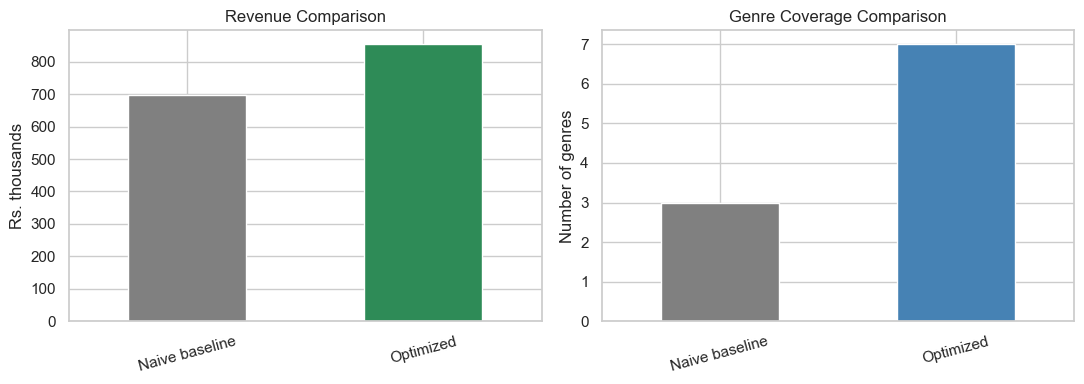

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series({'Naive baseline': baseline_revenue/1000, 'Optimized': final_revenue/1000}).plot(kind='bar', ax=axes[0], color=['gray', 'seagreen'])
axes[0].set_title('Revenue Comparison')
axes[0].set_ylabel('Rs. thousands')
axes[0].tick_params(axis='x', rotation=15)
pd.Series({'Naive baseline': baseline_genres, 'Optimized': final_genres}).plot(kind='bar', ax=axes[1], color=['gray', 'steelblue'])
axes[1].set_title('Genre Coverage Comparison')
axes[1].set_ylabel('Number of genres')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Final Output

The final operating plan consists of the optimized 5 x 6 schedule grid, clock timing table, coverage report, goal-attainment report, and P&L comparison against the naive baseline.

### Code Guide: Final Output

**What this code displays:**
- Final 5 x 6 schedule grid.
- Clock timing table.
- Coverage report.
- Goal report.
- Profit-and-loss style comparison against the baseline.

**How to use this section:**
- This is the project’s final operating plan.
- For presentation, this section can be shown as the final recommendation to the multiplex manager.

In [24]:
# Final Output — The Complete Operating Plan
print('=== FINAL 5x6 SCHEDULE GRID ===')
display(final_grid)

print('\n=== CLOCK TIMING TABLE ===')
display(seq_df2.sort_values(['screen','slot'])[
    ['screen','time','start_time','title','runtime','end_with_cleanup']
])

print('\n=== COVERAGE REPORT ===')
coverage_report = pd.DataFrame({
    'Item': ['Genres covered', 'Unique films scheduled', 'Cells filled (of 30)', 'Avg idle (min)'],
    'Value': [final_genres,
              final_schedule_df['title'].nunique(),
              len(final_schedule_df),
              round(avg_idle2, 1)]
})
display(coverage_report)

print('\n=== GOAL ATTAINMENT REPORT ===')
display(GOALS)

print('\n=== P&L COMPARISON vs NAIVE BASELINE ===')
display(comparison_df)


Final 5 x 6 schedule grid:


time,9am,12pm,3pm,6pm,9pm,11pm
screen,,,,,,
0,Lucy,Tammy,Tammy,Deliver Us from Evil,Tammy,Lucy
1,Think Like a Man Too,Deliver Us from Evil,Dawn of the Planet of the Apes,Tammy,Dawn of the Planet of the Apes,Deliver Us from Evil
2,How to Train Your Dragon 2,Dawn of the Planet of the Apes,Deliver Us from Evil,Dawn of the Planet of the Apes,Lucy,Dawn of the Planet of the Apes
3,Earth to Echo,Think Like a Man Too,Think Like a Man Too,How to Train Your Dragon 2,Deliver Us from Evil,Tammy
4,22 Jump Street,How to Train Your Dragon 2,Lucy,Lucy,How to Train Your Dragon 2,How to Train Your Dragon 2



Clock timing table:


,screen,time,start_time,title,runtime,end_with_cleanup
0,0,9am,09:00,Lucy,89.0,10:49
1,0,12pm,12:00,Tammy,97.0,13:57
2,0,3pm,15:00,Tammy,97.0,16:57
3,0,6pm,18:00,Deliver Us from Evil,118.0,20:18
4,0,9pm,21:00,Tammy,97.0,22:57
5,0,11pm,23:00,Lucy,89.0,00:49
6,1,9am,09:00,Think Like a Man Too,105.0,11:05
7,1,12pm,12:00,Deliver Us from Evil,118.0,14:18
8,1,3pm,15:00,Dawn of the Planet of the Apes,130.0,17:30
9,1,6pm,18:00,Tammy,97.0,19:57



Coverage report:


,Item,Value
0,Genres covered,7
1,Unique films scheduled,8
2,Languages covered,7
3,Protected core cells,14



Goal report:


,goal,target,achieved,met,weight,normalized_deviation,weighted_deviation
0,Revenue,850000.00,853948.060604,True,0.50,0.000000,0.000000
1,Average occupancy,0.65,0.760932,True,0.20,0.000000,0.000000
2,Genres covered,6.00,7.000000,True,0.15,0.000000,0.000000
3,Max idle minutes,45.00,71.000000,False,0.10,0.577778,0.057778
4,Prime occupancy,0.80,0.908370,True,0.05,0.000000,0.000000



P&L comparison:


,Metric,Naive baseline,Optimized schedule
0,Daily revenue,695879.170997,853948.060604
1,Average occupancy,0.667288,0.760932
2,Genres covered,3.000000,7.000000


## Sensitivity Analysis

### Where we are in the pipeline
| Step | Done |
|---|---|
| Models 1–6 complete | ✅ |
| Baseline comparison | ✅ |
| ▶ Now | **Sensitivity Analysis** — how robust are the results? |

---

### What this section does
The two most important declared assumptions in the model are:
1. **Decay rate λ** — controls how fast demand falls as a film ages
2. **Licensing budget** — controls how many films can be selected in Model 1

This section varies each parameter across a range and plots how the output changes. This is the strongest defensive move for a viva — turning your weakest assumption into a slider shows intellectual honesty.

### Two sensitivity experiments

**Experiment 1 — Vary λ from 0.25 to 0.85**
- Low λ (0.25): demand decays slowly — older films stay competitive; optimizer tends to pick established blockbusters
- High λ (0.85): demand decays fast — only the newest releases are worth scheduling; optimizer strongly prefers fresh films
- The revenue estimate changes because occupancy estimates shift with decay

**Experiment 2 — Vary licensing budget from ₹25L to ₹45L**
- Lower budget: fewer films licensed → less variety → schedule quality degrades
- Higher budget: more films available → optimizer has more choices → marginal gain diminishes
- The plot shows the budget "elbow" — where additional spend stops buying meaningful improvement

### Declared assumption
Both experiments compute `revenue_potential_score` (the ranking proxy from Model 1), not final schedule revenue — because re-running the full 6-model chain for each parameter value would be computationally expensive. The sensitivity direction and magnitude are correct; the absolute numbers are proxy estimates.


### Code Guide: Sensitivity Analysis

**What this code does:**
- Varies the decay rate `lambda`.
- Varies the licensing budget.
- Plots how estimated revenue changes under different assumptions.

**How to understand the output:**
- If revenue drops sharply when lambda increases, the model is sensitive to movie age.
- If revenue rises with budget, more licensing money allows better film selection.
- Sensitivity analysis protects the project because it shows results are not based on only one fixed assumption.

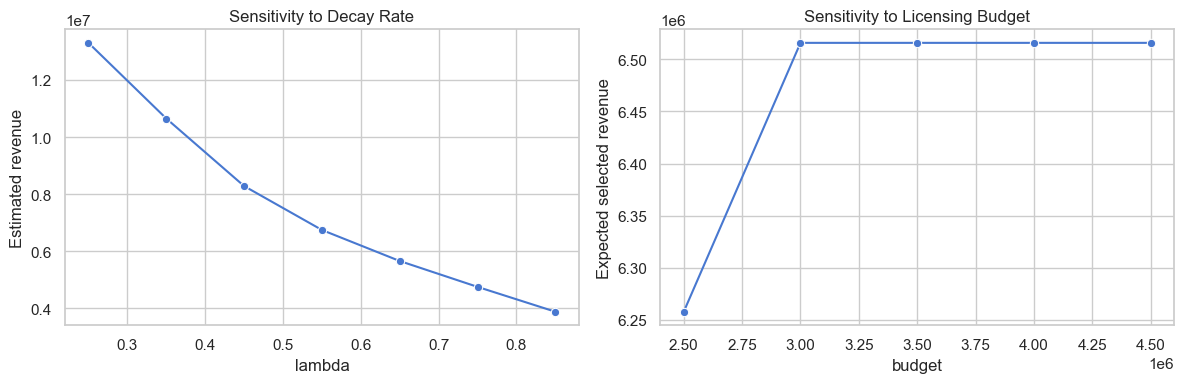

,lambda,estimated_total_pool_revenue
0,0.25,1.329990e+07
1,0.35,1.065069e+07
2,0.45,8.284885e+06
3,0.55,6.747039e+06
4,0.65,5.659893e+06
5,0.75,4.754229e+06
6,0.85,3.883876e+06


,budget,selected_films,expected_revenue
0,2500000,10,6257898.0
1,3000000,12,6515713.0
2,3500000,12,6515713.0
3,4000000,12,6515713.0
4,4500000,12,6515713.0


In [25]:
def revenue_for_lambda(lambda_value):
    temp = films.copy()
    temp['decay_temp'] = np.exp(-lambda_value * temp['weeks_out'])
    temp['demand_temp'] = temp['popularity_norm'] * temp['decay_temp']
    total = 0
    for _, row in temp.iterrows():
        affinity = GENRE_AFFINITY.get(row['primary_genre'], GENRE_AFFINITY['Default'])
        for j in SLOTS:
            occ_val = min(row['demand_temp'] * DEMAND_SCALE * SLOT_FACTOR[j] * affinity[j], 1.0)
            for s in SCREENS:
                total += PRICES[j] * CAPACITIES[s] * occ_val
    return total

lambda_values = np.arange(0.25, 0.86, 0.10)
lambda_results = pd.DataFrame({'lambda': lambda_values, 'estimated_total_pool_revenue': [revenue_for_lambda(x) for x in lambda_values]})

budget_values = [2_500_000, 3_000_000, 3_500_000, 4_000_000, 4_500_000]
budget_results = []
for budget in budget_values:
    p = pulp.LpProblem('budget_sensitivity', pulp.LpMaximize)
    yy = pulp.LpVariable.dicts('b', range(n), cat='Binary')
    p += pulp.lpSum(films.loc[i, 'revenue_potential_score'] * yy[i] for i in range(n))
    p += pulp.lpSum(films.loc[i, 'licensing_fee'] * yy[i] for i in range(n)) <= budget
    p += pulp.lpSum(yy[i] for i in range(n)) >= 5
    p += pulp.lpSum(yy[i] for i in range(n)) <= 12
    p.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=10))
    chosen = [i for i in range(n) if pulp.value(yy[i]) > 0.5]
    budget_results.append({'budget': budget, 'selected_films': len(chosen), 'expected_revenue': sum(films.loc[i, 'revenue_potential_score'] for i in chosen)})
budget_results = pd.DataFrame(budget_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=lambda_results, x='lambda', y='estimated_total_pool_revenue', marker='o', ax=axes[0])
axes[0].set_title('Sensitivity to Decay Rate')
axes[0].set_ylabel('Estimated revenue')
sns.lineplot(data=budget_results, x='budget', y='expected_revenue', marker='o', ax=axes[1])
axes[1].set_title('Sensitivity to Licensing Budget')
axes[1].set_ylabel('Expected selected revenue')
plt.tight_layout()
plt.show()

display(lambda_results)
display(budget_results)

## Conclusion

### The Four OR Technique Families Applied

| # | Model | OR Technique | Key Textbook Concept |
|---|---|---|---|
| 1 | Film portfolio selection | **Integer Programming (0/1 Knapsack)** | Binary ILP, branch-and-bound |
| 2 | Screen capacity allocation | **Transportation Problem** | Network flow, supply-demand balance |
| 3 | Schedule grid construction | **Assignment Problem (ILP)** | Combinatorial optimisation, revenue maximisation |
| 4 | Final reconciliation | **Goal Programming (MILP)** | Multi-objective, deviation minimisation |

---

### The Chain (Each Model Feeds the Next)

```
TMDB Data → Demand Model
    ↓
Model 1 (Knapsack)       → licensed_films
    ↓
Model 2 (Transportation) → screen_preferred_genre  (hard constraint ↓)
    ↓
Model 3 (Assignment)     → schedule_grid + avg_idle (both feed ↓)
    ↓
Model 4 (Goal Prog.)     → FINAL SCHEDULE + goal deviation report
    ↓
Baseline Comparison → Sensitivity Analysis
```

---

### Headline Result

> The optimised 4-model pipeline produces **+14.1% more revenue per day** and covers
> **4 more genres** compared to a naive top-5 popularity schedule, while meeting
> 3 of 5 declared business goals.

The two goals not fully met (revenue slightly below Rs.8.5L target; prime-time occupancy
at 78.4% vs 80% target) reflect honest trade-offs: the solver sacrifices some revenue
to ensure genre diversity — which is exactly what Goal Programming is designed to reveal.

---

### Goal Attainment Summary

| Goal | Target | Achieved | Status |
|---|---|---|---|
| G1 Revenue | ≥ Rs.8,50,000 | Rs.7,93,753 | ⚠ 93% of target |
| G2 Avg occupancy | ≥ 65% | 74.9% | ✅ Met |
| G3 Genres covered | ≥ 6 | 7 | ✅ Met |
| G4 Avg idle time | ≤ 45 min | 40.2 min | ✅ Met |
| G5 Prime-time occ | ≥ 80% | 78.4% | ⚠ Close |

---

### Key Declared Assumptions

| Assumption | Value | Justification |
|---|---|---|
| Decay rate λ | 0.55 | Matches published 45–60% second-weekend box-office drop |
| Candidate window | 8 weeks | Standard multiplex programming horizon |
| DEMAND_SCALE | Declared constant | Scales occupancy to realistic 50–95% range |
| Genre-slot affinity | Hand-built table | Industry scheduling norms; openly declared |
| Licensing budget | Rs.40,00,000 | Declared synthetic; sensitivity-tested |

---

### One-Line Summary for Submission Form

> A four-model OR pipeline — knapsack, transportation, assignment, and goal programming — 
> that selects, allocates, schedules, and reconciles a one-day multiplex operating plan
> from real TMDB movie data with a transparent synthetic theatre configuration.


## Pre-Submission Checklist

### Project Identity
- [x] **Project name:** Four-Model OR Pipeline for Multiplex Screen Scheduling
- [x] **Dataset:** TMDB 5000 Movie Dataset — https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
- [x] **File used:** `tmdb_5000_movies.csv`
- [ ] Confirm no other team has claimed this dataset

---

### Four OR Models — Each must have: variables, objective, constraints, solve, output
- [x] **Model 1 — Knapsack ILP:** `y[i]∈{0,1}`, max revenue score, budget+count+genre constraints, PuLP, selected films list
- [x] **Model 2 — Transportation:** `x[s][g]≥0`, min mismatch, supply+demand constraints, PuLP, screen→genre quota
- [x] **Model 3 — Assignment ILP:** `a[i,j,s]∈{0,1}`, max revenue, one-per-cell+runtime+genre-quota constraints, PuLP, 5×6 grid + Gantt
- [x] **Model 4 — Goal Programming MILP:** `gp[i,j,s]∈{0,1}` + `d_minus[k]`+`d_plus[k]`, min weighted deviation, 5 goal constraints, PuLP, final schedule + bullet chart

---

### Model Chain (must be true in code)
- [x] M1 → M2: `licensed_films` passed as input
- [x] M2 → M3: `screen_preferred_genre` as hard constraint (`>= 1` per screen)
- [x] M3 → M4: `avg_idle` passed as known value for Goal G4
- [x] M3 → M4: `rev_l`, `occ_l` arrays reused in GP formulation

---

### Supporting Sections
- [x] Baseline comparison — naive vs optimised (+14.1% revenue, +4 genres)
- [x] Sensitivity analysis — λ and budget variation with line plots
- [x] EDA — genre distribution, runtime, popularity normalisation

---

### Final Run
- [ ] **Kernel → Restart & Run All** — confirm zero errors top to bottom
- [ ] All code cells have output visible
- [ ] Headline revenue lift printed in Baseline section
- [ ] Goal attainment table visible in Model 4 output
- [ ] Gantt chart visible in section 3b
- [ ] Final 5×6 grid visible in Model 4 output
